In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm
from icecream import ic

from msfm.grid_pipeline import GridPipeline
from msfm.utils import logger, input_output, files, scales, power_spectra, parameters

from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization
from deep_lss.nets.mlp import MultiLayerPerceptron

from msi.utils import preprocessing, dataset

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [4]:
batch_size = 2**12
# batch_size = 2**8
shuffle_buffer = 4*batch_size

l_mins = 8 * [30]
def angle_to_ell(angles):
    return list(scales.angle_to_ell(np.array(angles), arcmin=True))
l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])
n_bins = 33

apply_log = True
standardize = True
pca_components = None

cl_dset_train, cl_dset_test, out_dict = dataset.get_binned_power_spectra_dset(
    base_dir, 
    # configuration
    conf=conf, 
    params=params,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    # dset
    batch_size=batch_size,
    shuffle_buffer=shuffle_buffer,
    # power spectra
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    pca_components=pca_components,

)

24-08-22 07:18:24 preprocessin INF   Applying scale cuts to the raw Cls 
24-08-22 07:18:24 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-08-22 07:18:24 preprocessin INF   l_maxs = [488.6877828054298, 715.2317880794702, 964.2857142857142, 1148.936170212766, 165.89861751152074, 242.69662921348313, 316.7155425219941, 378.94736842105266] 
24-08-22 07:18:27 input_output INF   Array shapes: 
24-08-22 07:18:27 input_output INF   fiducial/i_example = (40000,) 
24-08-22 07:18:27 input_output INF   fiducial/i_noise   = (40000,) 
24-08-22 07:18:27 input_output INF   fiducial/cls/binned = (40000, 32, 36) 
24-08-22 07:18:27 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-08-22 07:18:27 input_output INF   grid/cosmo         = (2500, 240, 12) 
24-08-22 07:18:27 input_output INF   grid/i_example     = (2500, 240) 
24-08-22 07:18:27 input_output INF   grid/i_noise       = (2500, 240) 
24-08-22 07:18:27 input_output INF   grid/i_sobol       = (2500, 240) 
24-08-22 07:18:28 in

In [5]:
n_cls = out_dict["grid/cls/train"].shape[-1]
n_params = len(params)
# n_summary = 2 * n_params
n_summary = n_params
num_hidden_units = 256
num_layers = 4
dropout_rate = 0.1

def get_cl_summary_network(n_summary=n_summary):
    mlp = MultiLayerPerceptron(
        output_size=n_summary, 
        num_hidden_units=num_hidden_units, 
        num_layers=num_layers, 
        dropout_rate=dropout_rate
    )
    mlp.build((None, n_cls))
    
    return mlp

In [6]:
n_steps = 10_000

def train_model(model, do_validation=True):
    train_losses = []
    train_steps = []
    vali_steps = []
    vali_losses = []
    for i, (cl_batch, cosmo_batch) in tqdm(enumerate(cl_dset_train.take(n_steps+1)), total=n_steps):
        train_losses.append(model.grid_train_step(cl_batch, cosmo_batch))
        train_steps.append(i)
        
        if i % 1_000 == 0 and i !=0 and do_validation:
            vali_loss = []
            for cl_batch, cosmo_batch in cl_dset_test:
                vali_loss.append(model.vali_loss_fn(model(cl_batch, training=False), cosmo_batch))
            vali_losses.append(np.mean(vali_loss))
            vali_steps.append(i)

    fig, ax = plt.subplots()
    ax.plot(train_steps[100:], train_losses[100:], label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend()

# Jensen-Shannon-Divergence (JSD)

In [7]:
# jsd_model = GridLossModel(
#     get_cl_summary_network(),
#     n_side=None,
#     indices=None,
# )

# jsd_model.setup_grid_loss_step(
#     batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_summary=n_summary,
#     dim_full=n_cls,
#     mutual_info_estimator="variational",
#     clip_by_global_norm=None,
# )

In [8]:
# train_model(jsd_model)

In [9]:
# np.save("./predictions/mutual(jsd)_grid_preds.npy", S(out_dict["grid/cls/test"]))
# np.save("./predictions/mutual(jsd)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
# np.save("./predictions/mutual(jsd)_fidu_preds.npy", S(out_dict["fidu/cls"]))

# Distance Correlation (DC)

In [10]:
# summary_net = get_cl_summary_network()

# dc_model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
# )

# dc_model.setup_grid_loss_step(
#     batch_size=batch_size,
#     dim_theta=n_params,
#     loss="mutual_info",
#     dim_x=n_cls,
#     dim_summary=n_summary,
#     mutual_info_estimator="distance_correlation",
#     clip_by_global_norm=None,
# )

In [11]:
# train_model(dc_model)

In [12]:
# np.save("./predictions/mutual(dc)_grid_preds.npy", dc_model(out_dict["grid/cls/test"]))
# np.save("./predictions/mutual(dc)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
# np.save("./predictions/mutual(dc)_fidu_preds.npy", dc_model(out_dict["fidu/cls"]))

# variational lower bound

In [13]:
summary_net = get_cl_summary_network()

var_model = GridLossModel(
    summary_net,
    n_side=None,
    indices=None,
)

var_model.setup_grid_loss_step(
    batch_size=batch_size,
    dim_theta=n_params,
    loss="mutual_info",
    dim_x=n_cls,
    dim_summary=n_summary,
    mutual_info_estimator="variational",
    clip_by_global_norm=1.0,
)

24-08-22 07:18:41 base_model.p INF   Initializing with a normal Sequential model 
24-08-22 07:18:41 base_model.p INF   The network is initialized from scratch. 
24-08-22 07:18:41 grid_model.p INF   Initialized the GridLossModel 
24-08-22 07:18:42 grid_model.p WAR   Using the mutual information loss with the variational estimator 
24-08-22 07:18:42 grid_model.p INF   Set up the training step of the mutual_info loss 


  0%|          | 0/10000 [00:00<?, ?it/s]

24-08-22 07:18:43 grid_model.p WAR   Tracing grid_train_step 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
24-08-22 07:18:45 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
24-08-22 07:18:45 grid_model.p WAR   Tracing grid_train_step 
24-08-22 07:18:45 base_model.p W

10001it [01:15, 133.14it/s]                          


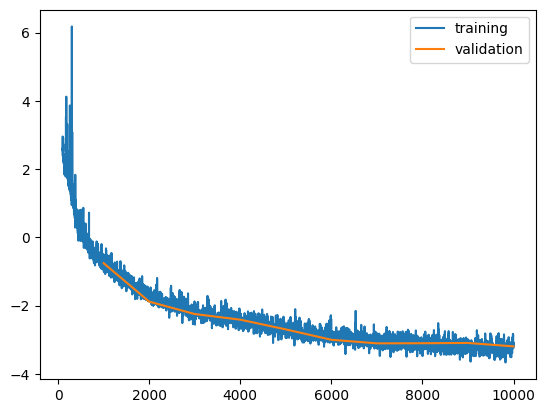

In [14]:
train_model(var_model, do_validation=True)

In [15]:
np.save("./predictions/mutual(var)_grid_preds.npy", var_model(out_dict["grid/cls/test"]))
np.save("./predictions/mutual(var)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
np.save("./predictions/mutual(var)_fidu_preds.npy", var_model(out_dict["fidu/cls"]))

In [16]:
# np.save("./predictions/mutual(var)_grid_preds_train.npy", var_model(out_dict["grid/cls/train"]))
# np.save("./predictions/mutual(var)_grid_cosmos_train.npy", out_dict["grid/cosmos/train"])
# np.save("./predictions/mutual(var)_fidu_preds_train.npy", var_model(out_dict["fidu/cls"]))

# MSE

In [17]:
# summary_net = get_cl_summary_network(n_summary=n_params)

# mse_model = GridLossModel(
#     summary_net,
#     n_side=None,
#     indices=None,
# )

# mse_model.setup_grid_loss_step(
#     batch_size=batch_size,
#     loss="mse",
#     dim_theta=n_params,
#     dim_summary=n_params,
#     clip_by_global_norm=None,
# )

In [18]:
# train_model(mse_model, do_validation=True)

In [19]:
# np.save("./predictions/mutual(mse)_grid_preds.npy", var_model(out_dict["grid/cls/test"]))
# np.save("./predictions/mutual(mse)_grid_cosmos.npy", out_dict["grid/cosmos/test"])
# np.save("./predictions/mutual(mse)_fidu_preds.npy", var_model(out_dict["fidu/cls"]))